# Groundwater Productivity Overlay

## Purpose

Assign the BGS / MacDonald et al. groundwater productivity map value to each CPIS centroid. The source map is a 5 km continental-scale grid of representative borehole yield classes in liters per second, so the primary CPIS groundwater indicator is the direct nearest-source-map value, not a smoothed interpolation.

## Context

This notebook is supporting evidence for water-source attribution. It does not prove groundwater use at a CPIS; it identifies whether CPIS are located in areas where the regional aquifer productivity map suggests groundwater could plausibly support higher-yield abstraction.

## Inputs

| Dataset | Config key | Notes |
|---------|------------|-------|
| Groundwater productivity | `Groundwater_Prod_gpkg_path` | Built from raw BGS xyz ASCII by `Code/0_process_data/7_Groundwater_Processing.ipynb` |
| CPIS polygons | `SSA_Combined_CPIS_All_shp_path` | Arid SSA CPIS polygons |
| Arid SSA boundaries | `SSA_All_by_Country_shp_path` | Country labels and map background |
| Elevation classification | `CPIS_Elevation_Classified_shp_path` | Optional; used for summary cross-tabs |

## Outputs

| File | Config key | Description |
|------|------------|-------------|
| `CPIS_Groundwater_Productivity.csv` | `CPIS_GP_Groundwater_csv_path` | Direct source-map groundwater productivity at each CPIS centroid |


In [1]:
# --- Import required libraries and utilities ---
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from Code.utils.utility import load_config, resolve_path

config = load_config()

## Load Groundwater Productivity Data

The BGS source map uses representative yield values for productivity classes. We keep both the numeric representative value and the class/range labels.

In [2]:
# --- Load groundwater productivity data ---
gw = gpd.read_file(resolve_path(config['Groundwater_Prod_gpkg_path'])).to_crs('EPSG:4326')
print(f"Groundwater productivity points loaded: {len(gw):,}")
print(f"CRS: {gw.crs}")
print(f"Columns: {list(gw.columns)}")

prod_col = 'Liters_Second'
if prod_col not in gw.columns:
    candidates = [
        c for c in gw.columns
        if c.lower() in ('liters_second', 'litres_second', 'liter_second', 'lps')
    ]
    if not candidates:
        raise KeyError('Could not find a Liters_Second groundwater productivity column.')
    prod_col = candidates[0]

gw[prod_col] = pd.to_numeric(gw[prod_col], errors='coerce')
gw_valid = gw[gw[prod_col].notna() & (gw[prod_col] > 0)].copy()

class_lookup = {
    0.1: ('Very low', '<0.1 L/s'),
    0.3: ('Low', '0.1-0.5 L/s'),
    0.75: ('Low to moderate', '0.5-2 L/s'),
    3.0: ('Moderate', '2-5 L/s'),
    12.5: ('High', '5-20 L/s'),
    20.0: ('Very high', '>20 L/s'),
}
if 'productivity_class' not in gw_valid.columns:
    gw_valid['productivity_class'] = gw_valid[prod_col].map(lambda v: class_lookup.get(float(v), (np.nan, np.nan))[0])
if 'yield_range' not in gw_valid.columns:
    gw_valid['yield_range'] = gw_valid[prod_col].map(lambda v: class_lookup.get(float(v), (np.nan, np.nan))[1])

print('\nProductivity value counts:')
print(gw_valid[prod_col].value_counts().sort_index())
print('\nProductivity class counts:')
print(gw_valid['productivity_class'].value_counts(dropna=False))

Groundwater productivity points loaded: 1,008,704
CRS: EPSG:4326
Columns: ['X', 'Y', 'gwprod_code', 'Liters_Second', 'productivity_class', 'yield_range', 'geometry']

Productivity value counts:
Liters_Second
0.10      29683
0.30     176127
0.75     184202
3.00     270050
12.50    262623
20.00     86019
Name: count, dtype: int64

Productivity class counts:
productivity_class
Moderate           270050
High               262623
Low to moderate    184202
Low                176127
Very high           86019
Very low            29683
Name: count, dtype: int64


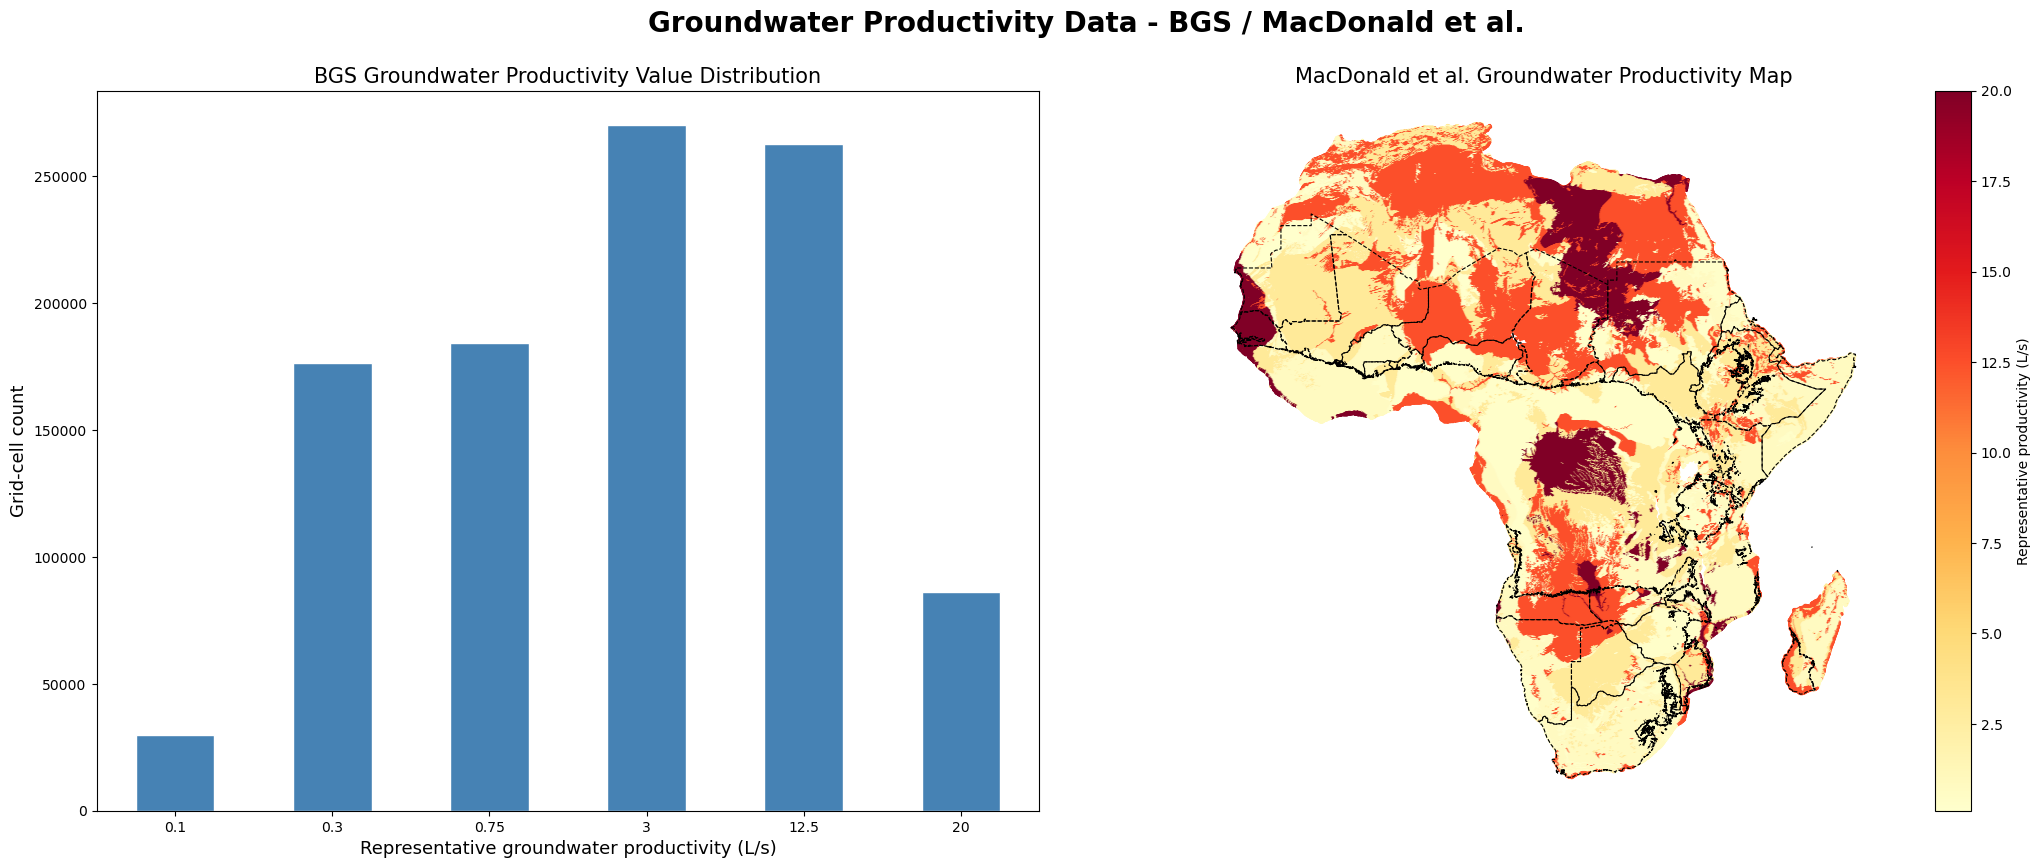

In [3]:
# --- Exploratory visualization of source map ---
arid_ssa = gpd.read_file(resolve_path(config['SSA_All_by_Country_shp_path'])).to_crs('EPSG:4326')
arid_ssa['geometry'] = arid_ssa['geometry'].simplify(0.01)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
plt.subplots_adjust(wspace=0.1, left=0.05, right=0.95, top=0.88, bottom=0.08)

gw_valid[prod_col].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Representative groundwater productivity (L/s)', fontsize=13)
axes[0].set_ylabel('Grid-cell count', fontsize=13)
axes[0].set_title('BGS Groundwater Productivity Value Distribution', fontsize=15)
axes[0].set_xticklabels([f'{v:g}' for v in sorted(gw_valid[prod_col].unique())], rotation=0)

arid_ssa.boundary.plot(ax=axes[1], color='black', linewidth=0.8, linestyle='--')
gw_valid.plot(
    column=prod_col, ax=axes[1], cmap='YlOrRd', markersize=1,
    vmin=gw_valid[prod_col].min(), vmax=gw_valid[prod_col].max(),
    legend=True,
    legend_kwds={'label': 'Representative productivity (L/s)', 'orientation': 'vertical'},
)
axes[1].set_title('MacDonald et al. Groundwater Productivity Map', fontsize=15)
axes[1].set_axis_off()

fig.suptitle('Groundwater Productivity Data - BGS / MacDonald et al.', fontsize=20, fontweight='bold', y=0.97)
plt.show()

## Assign Groundwater Productivity to CPIS

For each CPIS, use its centroid in EPSG:4326 and assign the nearest BGS source-grid value. This preserves the source map's categorical meaning and avoids inventing sub-class gradients.

In [4]:
# --- Assign nearest source-map groundwater productivity to each CPIS ---
cpis = gpd.read_file(resolve_path(config['SSA_Combined_CPIS_All_shp_path']))
cpis_ll = cpis.to_crs('EPSG:4326')
cpis_centroids = cpis_ll.geometry.centroid

cpis_gw = pd.DataFrame(index=cpis.index)
cpis_gw['lon'] = cpis_centroids.x
cpis_gw['lat'] = cpis_centroids.y

gw_coords = np.column_stack([gw_valid.geometry.x, gw_valid.geometry.y])
cpis_coords = cpis_gw[['lon', 'lat']].values
gw_tree = cKDTree(gw_coords)
dist_deg, idx = gw_tree.query(cpis_coords, k=1)

nearest = gw_valid.iloc[idx].reset_index(drop=True)
cpis_gw['source_gw_productivity'] = nearest[prod_col].values.astype(float)
cpis_gw['productivity_class'] = nearest['productivity_class'].values
cpis_gw['yield_range'] = nearest['yield_range'].values
cpis_gw['source_gw_distance_deg'] = dist_deg
cpis_gw['source_gw_lon'] = nearest.geometry.x.values
cpis_gw['source_gw_lat'] = nearest.geometry.y.values

out_csv = resolve_path(config['CPIS_GP_Groundwater_csv_path'])
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
cpis_gw.to_csv(out_csv)
print(f'CPIS groundwater productivity saved: {out_csv}')

print('\nCPIS groundwater productivity counts:')
print(cpis_gw['source_gw_productivity'].value_counts().sort_index())
print('\nCPIS productivity class counts:')
print(cpis_gw['productivity_class'].value_counts(dropna=False))
print(f"\nRange: [{cpis_gw['source_gw_productivity'].min():.2f}, {cpis_gw['source_gw_productivity'].max():.2f}] L/s")

C:\Users\ermil\AppData\Local\Temp\ipykernel_33588\932059838.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cpis_centroids = cpis_ll.geometry.centroid


CPIS groundwater productivity saved: C:/Users/ermil/Documents/Africa_Irrigation\Data/Processed/CPIS_Groundwater_Productivity.csv

CPIS groundwater productivity counts:
source_gw_productivity
0.10       153
0.30      8030
0.75     14325
3.00      5015
12.50     1579
20.00      380
Name: count, dtype: int64

CPIS productivity class counts:
productivity_class
Low to moderate    14325
Low                 8030
Moderate            5015
High                1579
Very high            380
Very low             153
Name: count, dtype: int64

Range: [0.10, 20.00] L/s


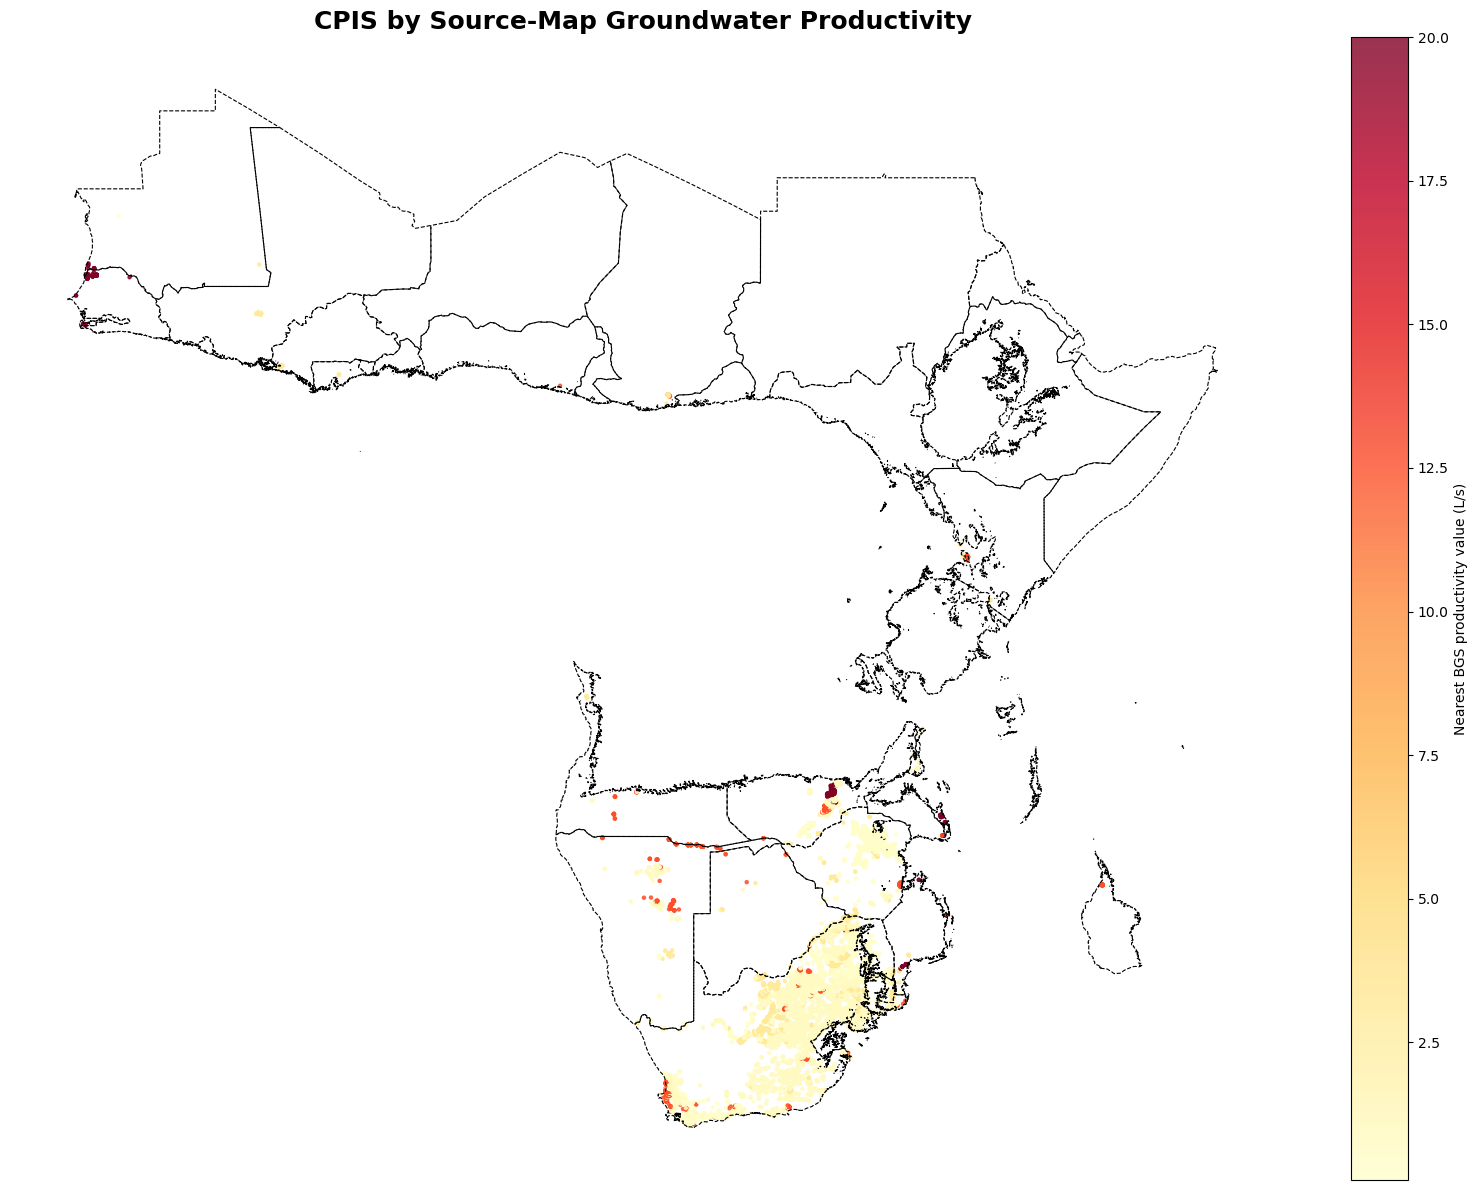

In [5]:
# --- Map CPIS by assigned groundwater productivity ---
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
arid_ssa.boundary.plot(ax=ax, color='black', linewidth=0.8, linestyle='--')

sc = ax.scatter(
    cpis_gw['lon'], cpis_gw['lat'],
    c=cpis_gw['source_gw_productivity'], cmap='YlOrRd',
    s=5, vmin=gw_valid[prod_col].min(), vmax=gw_valid[prod_col].max(), alpha=0.8,
)
plt.colorbar(sc, ax=ax, label='Nearest BGS productivity value (L/s)', fraction=0.04)
ax.set_title('CPIS by Source-Map Groundwater Productivity', fontsize=18, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Optional Summaries

If country boundaries or dam-accessibility classes are available, summarize groundwater productivity by those groupings.

In [6]:
# --- Country and dam-accessibility summaries ---
cpis_pts = gpd.GeoDataFrame(
    cpis_gw.copy(),
    geometry=gpd.points_from_xy(cpis_gw['lon'], cpis_gw['lat']),
    crs='EPSG:4326',
)

name_col = next(
    (c for c in arid_ssa.columns if c.lower() in ('name', 'country', 'adm0_name', 'name_long', 'sovereignt', 'admin')),
    arid_ssa.columns[0],
)
cpis_country = gpd.sjoin(cpis_pts, arid_ssa[[name_col, 'geometry']], how='left', predicate='within')

country_summary = (
    cpis_country.groupby(name_col, dropna=False)
    .agg(
        n_cpis=('source_gw_productivity', 'size'),
        median_gw_lps=('source_gw_productivity', 'median'),
        pct_high_ge_5_lps=('source_gw_productivity', lambda s: 100 * (s >= 5).mean()),
        pct_low_lt_2_lps=('source_gw_productivity', lambda s: 100 * (s < 2).mean()),
    )
    .sort_values(['n_cpis', 'median_gw_lps'], ascending=[False, False])
)
display(country_summary.round(2))

try:
    elev = gpd.read_file(resolve_path(config['CPIS_Elevation_Classified_shp_path']))
    access_col = 'accessibility' if 'accessibility' in elev.columns else 'elev_class'
    cpis_gw_access = cpis_gw.join(elev[[access_col]], how='left')
    access_summary = (
        cpis_gw_access.groupby(access_col, dropna=False)
        .agg(
            n_cpis=('source_gw_productivity', 'size'),
            median_gw_lps=('source_gw_productivity', 'median'),
            pct_high_ge_5_lps=('source_gw_productivity', lambda s: 100 * (s >= 5).mean()),
            pct_low_lt_2_lps=('source_gw_productivity', lambda s: 100 * (s < 2).mean()),
        )
        .sort_values('n_cpis', ascending=False)
    )
    display(access_summary.round(2))
except Exception as exc:
    print(f'Elevation accessibility summary skipped: {exc}')

,n_cpis,median_gw_lps,pct_high_ge_5_lps,pct_low_lt_2_lps
NAME,,,,
South Africa,25067,0.75,3.69,78.00
Zimbabwe,1859,0.30,3.12,93.65
Zambia,1192,0.75,36.58,58.39
Namibia,495,0.75,43.84,52.73
Botswana,194,0.75,3.09,73.20
Eswatini,161,3.00,0.00,31.06
Mozambique,84,20.00,75.00,1.19
Senegal,75,20.00,100.00,0.00
Kenya,65,12.50,75.38,4.62


Elevation accessibility summary skipped: "None of [Index(['elev_class'], dtype='object')] are in the [columns]"
